# Single-run enzyme explorer plots

Load one generated-sequences CSV and create the three enzyme-explorer style plots for a single dataset:

- Boxplot
- Violin plot
- Threshold counts

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

csv_path = Path("/Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval_2026_04_02/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv")
thresholds = [0.3, 0.5, 0.7, 0.9]

# Preferred score columns in priority order.
candidate_score_columns = [
    "isTPS",
    "isTPS ",
    "score",
    "prediction",
    "probability",
]

In [11]:
if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")

# Match columns case-insensitively while preserving the original name.
normalized_to_original = {col.strip().lower(): col for col in df.columns}
score_column = None

for candidate in candidate_score_columns:
    key = candidate.strip().lower()
    if key in normalized_to_original:
        score_column = normalized_to_original[key]
        break

if score_column is None:
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_columns:
        raise ValueError("No numeric columns available to plot.")
    score_column = numeric_columns[0]
    print(f"No preferred score column found; using numeric column: {score_column}")

scores = pd.to_numeric(df[score_column], errors="coerce").dropna()
if scores.empty:
    raise ValueError(f"Column '{score_column}' has no numeric values after cleanup.")

print(f"Using score column: {score_column}")
print(scores.describe(percentiles=[0.25, 0.5, 0.75]).to_string())

Loaded: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/checkpoint_eval_2026_04_02/generated_sequences/generated_sequences_enzyme_explorer_sequence_only.csv
Rows: 10 | Columns: 11
Using score column: isTPS 
count    10.000000
mean      0.901484
std       0.060909
min       0.821900
25%       0.839754
50%       0.917716
75%       0.959870
max       0.963146


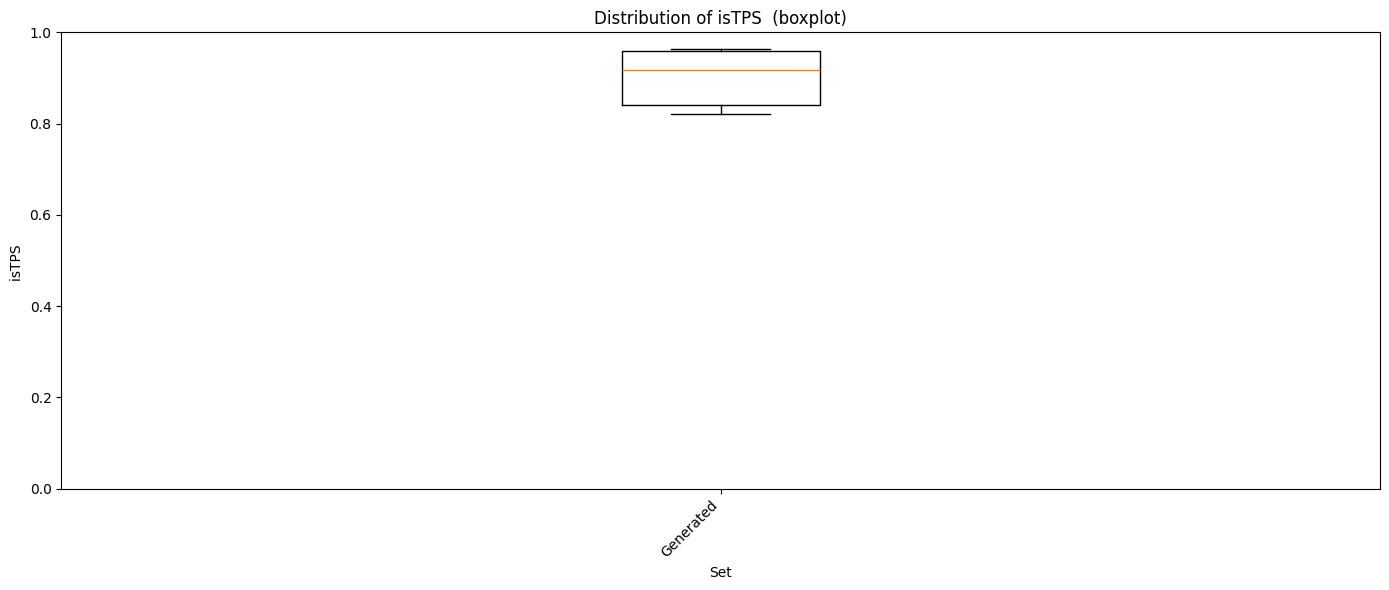

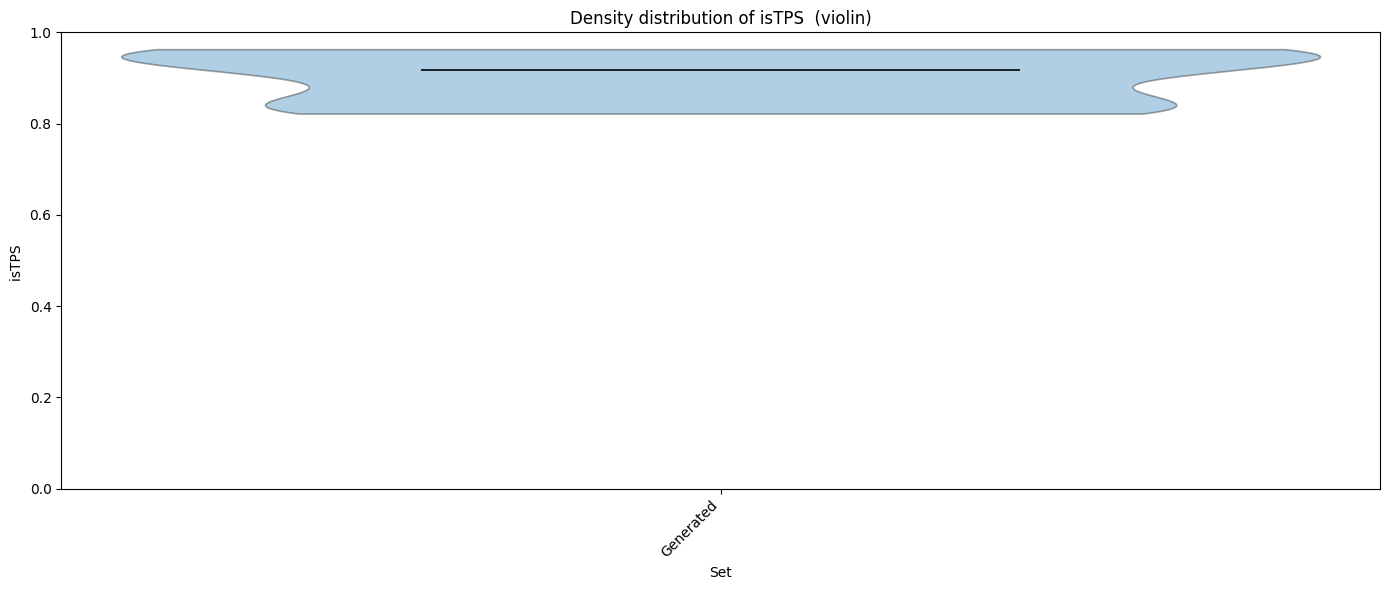

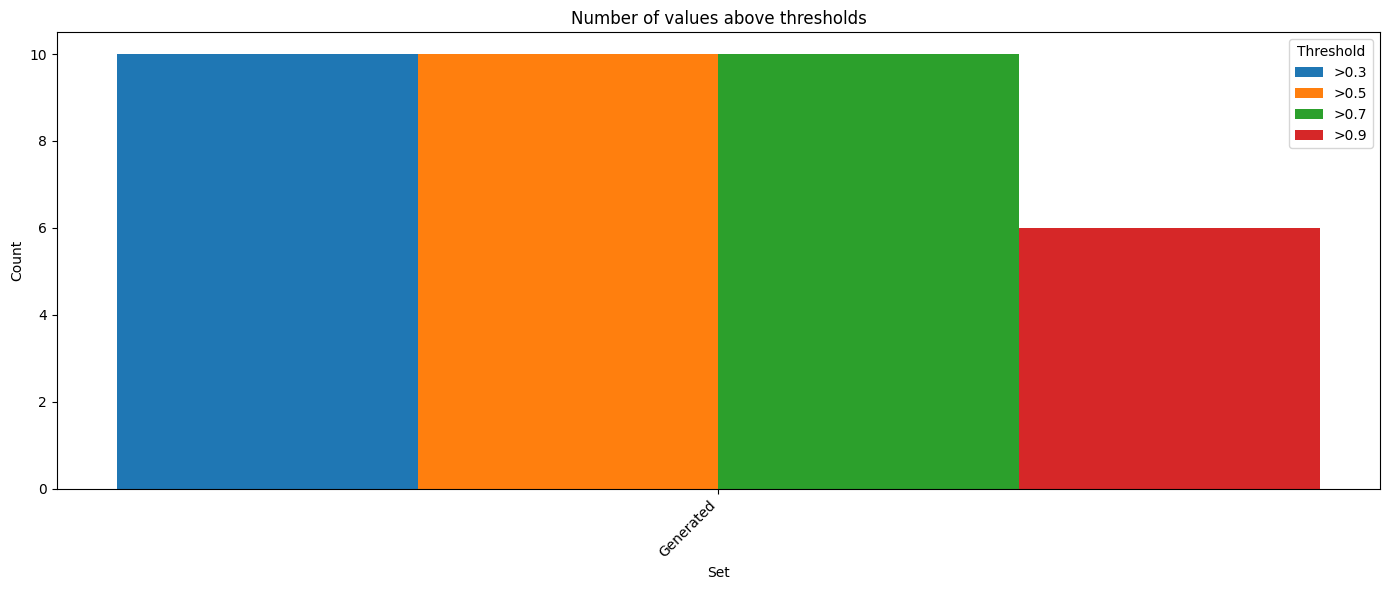

,>0.3,>0.5,>0.7,>0.9
Generated,10,10,10,6


In [13]:
import numpy as np
import pandas as pd

value_col = score_column
label_name = "Generated"

# --- 1) Boxplot (match original styling: default black lines) ---
box_data = [scores.values]
fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(box_data, tick_labels=[label_name])
ax.set_title(f"Distribution of {value_col} (boxplot)")
ax.set_xlabel("Set")
ax.set_ylabel(value_col)
ax.set_ylim(0.0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 2) Violin (match original styling colors) ---
violin_data = [pd.to_numeric(scores, errors="coerce").dropna().values]
fig3, ax3 = plt.subplots(figsize=(14, 6))
parts = ax3.violinplot(
    violin_data,
    positions=np.arange(1, 2),
    widths=0.9,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in parts["bodies"]:
    body.set_facecolor("#1f77b4")
    body.set_alpha(0.35)
    body.set_edgecolor("black")
    body.set_linewidth(1.2)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.2)

ax3.set_title(f"Density distribution of {value_col} (violin)")
ax3.set_xlabel("Set")
ax3.set_ylabel(value_col)
ax3.set_ylim(0.0, 1.0)
ax3.set_xticks(np.arange(1, 2))
ax3.set_xticklabels([label_name], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 3) Threshold counts (match original styling: different colors per threshold) ---
counts = pd.DataFrame(index=[label_name])
for threshold in thresholds:
    counts[f">{threshold}"] = [int((scores > threshold).sum())]

x = np.arange(len(counts.index))
width = 0.2

fig2, ax2 = plt.subplots(figsize=(14, 6))
for index, column in enumerate(counts.columns):
    ax2.bar(
        x + (index - (len(counts.columns) - 1) / 2) * width,
        counts[column].values,
        width=width,
        label=column,
    )

ax2.set_title("Number of values above thresholds")
ax2.set_xlabel("Set")
ax2.set_ylabel("Count")
ax2.set_xticks(x)
ax2.set_xticklabels(counts.index, rotation=45, ha="right")
ax2.legend(title="Threshold")
plt.tight_layout()
plt.show()

counts